# H4 - Performance a long terme des IPO (12 mois)

## Hypothese testee
La performance a 12 mois des IPO de la cohorte recente est superieure a celle de la cohorte 2019-2021.

## Perimetre retenu
- Cohorte de reference: **2019-2021**
- Cohorte recente analysee: **2022-2023 uniquement**

Les IPO de 2024 sont exclues car elles ne disposent pas toutes d'un recul de 12 mois suffisant.

## Protocole statistique
1. Comparaison descriptive des rendements a 12 mois (`ret_12m`).
2. Intervalles de confiance 95% (bootstrap) pour moyenne et mediane.
3. Test de Mann-Whitney unilateral (H1: 2022-2023 > 2019-2021).
4. Test t de Welch unilateral en complement.

## Donnees
- `data/dataset_complet_filled.xlsx`

> Aucune simulation n'est utilisee.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120})

SEED = 42
COLORS = {"2019-2021": "#2C7BB6", "2022-2023": "#D7191C"}

print("Imports OK")

Imports OK


In [2]:
DATA_PATH = "data/dataset_complet_filled.xlsx"
df = pd.read_excel(DATA_PATH)

required = ["year", "ret_12m"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

# Perimetre H4
# Groupe 1: 2019-2021
# Groupe 2: 2022-2023 (2024 exclu)
df = df[df["year"].between(2019, 2023)].copy()
df["cohort_h4"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2023")

# Optionnel: logique de filtre taille >= 50 M$ si disponible
if "ipo_size_m" in df.columns:
    df = df[(df["ipo_size_m"].isna()) | (pd.to_numeric(df["ipo_size_m"], errors="coerce") >= 50)].copy()

df["ret_12m"] = pd.to_numeric(df["ret_12m"], errors="coerce")
work = df.dropna(subset=["ret_12m"]).copy()

r_19_21 = work.loc[work["cohort_h4"] == "2019-2021", "ret_12m"].to_numpy()
r_22_23 = work.loc[work["cohort_h4"] == "2022-2023", "ret_12m"].to_numpy()

print(f"Fichier: {DATA_PATH}")
print(f"Lignes apres filtres (2019-2023): {len(df)}")
print("\nEffectifs ret_12m non manquants:")
print(work["cohort_h4"].value_counts())
print(f"\nN 2019-2021 = {len(r_19_21)}")
print(f"N 2022-2023 = {len(r_22_23)}")

Fichier: data/dataset_complet_filled.xlsx
Lignes apres filtres (2019-2023): 279

Effectifs ret_12m non manquants:
cohort_h4
2019-2021    237
2022-2023     42
Name: count, dtype: int64

N 2019-2021 = 237
N 2022-2023 = 42


In [3]:
def summarize_returns(label: str) -> dict:
    x = work.loc[work["cohort_h4"] == label, "ret_12m"].dropna().to_numpy()
    return {
        "Cohorte": label,
        "N": len(x),
        "Moyenne": np.mean(x) if len(x) else np.nan,
        "Mediane": np.median(x) if len(x) else np.nan,
        "Ecart-type": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "Q1": np.percentile(x, 25) if len(x) else np.nan,
        "Q3": np.percentile(x, 75) if len(x) else np.nan,
    }

desc = pd.DataFrame([
    summarize_returns("2019-2021"),
    summarize_returns("2022-2023")
])

display(desc.style.format({
    "Moyenne": "{:.4f}",
    "Mediane": "{:.4f}",
    "Ecart-type": "{:.4f}",
    "Q1": "{:.4f}",
    "Q3": "{:.4f}",
}))

,Cohorte,N,Moyenne,Mediane,Ecart-type,Q1,Q3
0,2019-2021,237,-0.0387,-0.3048,0.8881,-0.6163,0.2315
1,2022-2023,42,-0.0750,-0.1063,0.6115,-0.5866,0.2556


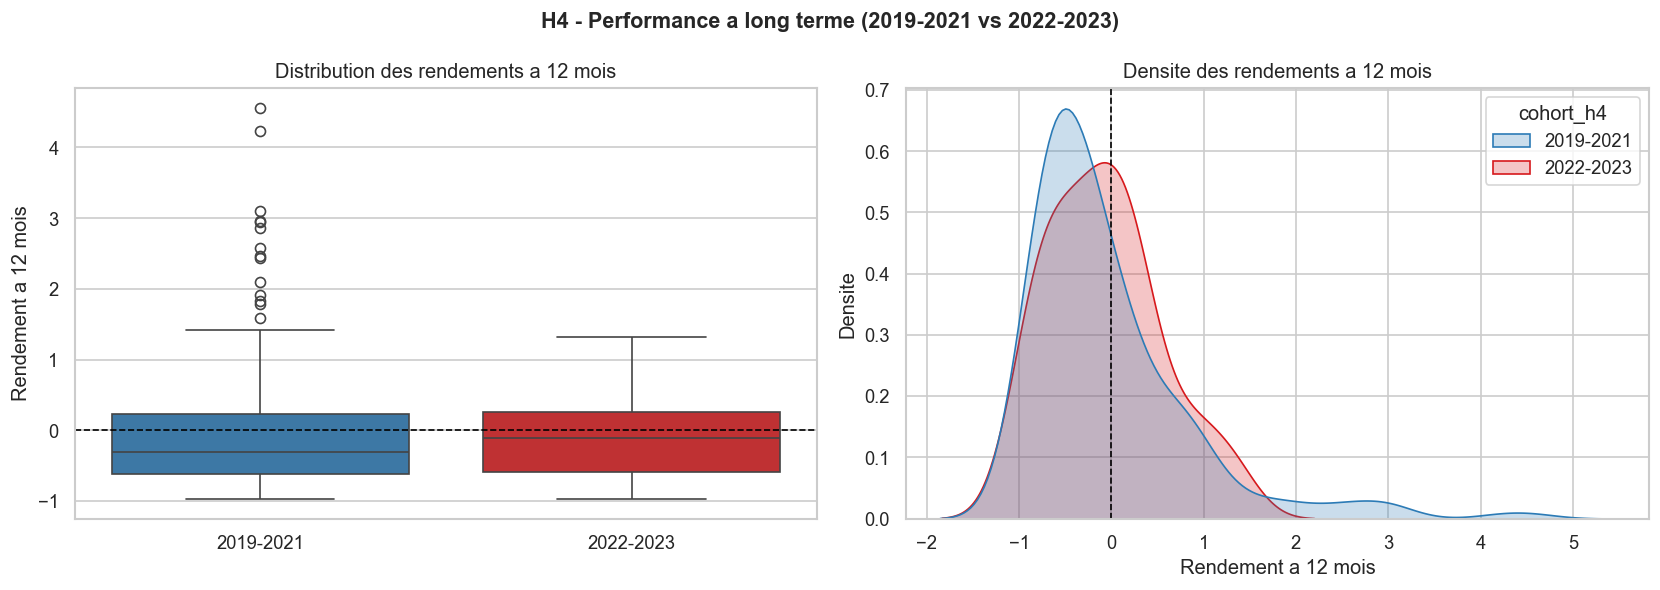

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(work) > 0 and work["cohort_h4"].nunique() >= 1:
    sns.boxplot(
        data=work,
        x="cohort_h4",
        y="ret_12m",
        order=["2019-2021", "2022-2023"],
        palette=[COLORS["2019-2021"], COLORS["2022-2023"]],
        ax=axes[0],
    )
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Rendement a 12 mois")
    axes[0].set_title("Distribution des rendements a 12 mois")

    if work["cohort_h4"].nunique() >= 2:
        sns.kdeplot(
            data=work,
            x="ret_12m",
            hue="cohort_h4",
            hue_order=["2019-2021", "2022-2023"],
            fill=True,
            common_norm=False,
            palette=[COLORS["2019-2021"], COLORS["2022-2023"]],
            alpha=0.25,
            ax=axes[1],
        )
        axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
        axes[1].set_xlabel("Rendement a 12 mois")
        axes[1].set_ylabel("Densite")
        axes[1].set_title("Densite des rendements a 12 mois")
    else:
        axes[1].text(0.5, 0.5, "Donnees insuffisantes pour densite comparee", ha="center", va="center")
        axes[1].axis("off")
else:
    axes[0].text(0.5, 0.5, "Aucune donnee ret_12m exploitable", ha="center", va="center")
    axes[0].axis("off")
    axes[1].axis("off")

fig.suptitle("H4 - Performance a long terme (2019-2021 vs 2022-2023)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
def bootstrap_ci_stat(x, stat_fn, n_boot=10_000, alpha=0.05, seed=SEED):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    boot = stat_fn(x[idx], axis=1)
    est = stat_fn(x)
    lo = np.quantile(boot, alpha / 2)
    hi = np.quantile(boot, 1 - alpha / 2)
    return est, lo, hi

mean_19, mean_19_lo, mean_19_hi = bootstrap_ci_stat(r_19_21, np.mean, seed=SEED)
mean_22, mean_22_lo, mean_22_hi = bootstrap_ci_stat(r_22_23, np.mean, seed=SEED + 1)

med_19, med_19_lo, med_19_hi = bootstrap_ci_stat(r_19_21, np.median, seed=SEED + 2)
med_22, med_22_lo, med_22_hi = bootstrap_ci_stat(r_22_23, np.median, seed=SEED + 3)

ci_table = pd.DataFrame({
    "Cohorte": ["2019-2021", "2022-2023"],
    "Moyenne": [mean_19, mean_22],
    "IC95 Moyenne": [f"[{mean_19_lo:.4f} ; {mean_19_hi:.4f}]", f"[{mean_22_lo:.4f} ; {mean_22_hi:.4f}]"],
    "Mediane": [med_19, med_22],
    "IC95 Mediane": [f"[{med_19_lo:.4f} ; {med_19_hi:.4f}]", f"[{med_22_lo:.4f} ; {med_22_hi:.4f}]"],
})

display(ci_table.style.format({
    "Moyenne": "{:.4f}",
    "Mediane": "{:.4f}",
}))

,Cohorte,Moyenne,IC95 Moyenne,Mediane,IC95 Mediane
0,2019-2021,-0.0387,[-0.1475 ; 0.0795],-0.3048,[-0.4079 ; -0.1883]
1,2022-2023,-0.0750,[-0.2507 ; 0.1068],-0.1063,[-0.3768 ; 0.1143]


In [21]:
alpha = 0.05

# Mann-Whitney unilateral: H1 = ret_12m 2022-2023 > 2019-2021
if len(r_19_21) > 0 and len(r_22_23) > 0:
    u_stat, p_mw = stats.mannwhitneyu(r_22_23, r_19_21, alternative="greater")
else:
    u_stat, p_mw = np.nan, np.nan

# Welch t-test unilateral (complement parametrique)
if len(r_19_21) > 1 and len(r_22_23) > 1:
    t_stat, p_welch_two_sided = stats.ttest_ind(r_22_23, r_19_21, equal_var=False, nan_policy="omit")
    # conversion bilaterale -> unilaterale pour H1 'greater'
    p_welch = (p_welch_two_sided / 2) if t_stat > 0 else (1 - p_welch_two_sided / 2)
else:
    t_stat, p_welch = np.nan, np.nan

results = pd.DataFrame({
    "Test": [
        "Mann-Whitney U (H1: ret_12m 2022-2023 > 2019-2021)",
        "Welch t-test unilateral (complement)",
    ],
    "Statistique": [u_stat, t_stat],
    "p-value": [p_mw, p_welch],
    "Significatif a 5%": [bool(np.isfinite(p_mw) and p_mw < alpha), bool(np.isfinite(p_welch) and p_welch < alpha)],
})

display(results.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

h4_mean_ok = bool(np.isfinite(mean_22) and np.isfinite(mean_19) and mean_22 > mean_19)
h4_med_ok = bool(np.isfinite(med_22) and np.isfinite(med_19) and med_22 > med_19)
h4_mw_ok = bool(np.isfinite(p_mw) and p_mw < alpha)

print("\n=== Decision H4 ===")
print("Condition direction moyenne (2022-2023 > 2019-2021):", "OK" if h4_mean_ok else "NON")
print("Condition direction mediane (2022-2023 > 2019-2021):", "OK" if h4_med_ok else "NON")
print("Condition Mann-Whitney (p < 0,05):", "OK" if h4_mw_ok else "NON")
print("Conclusion H4:", "CONFIRMEE" if (h4_mw_ok and (h4_mean_ok or h4_med_ok)) else "PARTIELLE/NON CONFIRMEE")

,Test,Statistique,p-value,Significatif a 5%
0,Mann-Whitney U (H1: ret_12m 2022-2023 > 2019-2021),5331.0000,0.2316,False
1,Welch t-test unilateral (complement),-0.3281,0.6281,False



=== Decision H4 ===
Condition direction moyenne (2022-2023 > 2019-2021): NON
Condition direction mediane (2022-2023 > 2019-2021): OK
Condition Mann-Whitney (p < 0,05): NON
Conclusion H4: PARTIELLE/NON CONFIRMEE


In [22]:
def fmt(x):
    return f"{x:.4f}" if np.isfinite(x) else "NA"

summary_final = pd.DataFrame({
    "Indicateur": [
        "Moyenne ret_12m",
        "IC95 moyenne",
        "Mediane ret_12m",
        "IC95 mediane",
        "p-value Mann-Whitney",
        "p-value Welch (complement)",
    ],
    "2019-2021": [
        fmt(mean_19),
        f"[{fmt(mean_19_lo)} ; {fmt(mean_19_hi)}]",
        fmt(med_19),
        f"[{fmt(med_19_lo)} ; {fmt(med_19_hi)}]",
        "",
        "",
    ],
    "2022-2023": [
        fmt(mean_22),
        f"[{fmt(mean_22_lo)} ; {fmt(mean_22_hi)}]",
        fmt(med_22),
        f"[{fmt(med_22_lo)} ; {fmt(med_22_hi)}]",
        "",
        "",
    ],
    "Valeur test": [
        "",
        "",
        "",
        "",
        fmt(p_mw),
        fmt(p_welch),
    ],
})

display(summary_final)

print("\nLecture:")
print("- H4 est soutenue si les rendements 12m de 2022-2023 sont plus eleves et si Mann-Whitney est significatif.")
print("- Le test de Welch est un controle complementaire parametrique.")

,Indicateur,2019-2021,2022-2023,Valeur test
0,Moyenne ret_12m,-0.0387,-0.0750,
1,IC95 moyenne,[-0.1475 ; 0.0795],[-0.2507 ; 0.1068],
2,Mediane ret_12m,-0.3048,-0.1063,
3,IC95 mediane,[-0.4079 ; -0.1883],[-0.3768 ; 0.1143],
4,p-value Mann-Whitney,,,0.2316
5,p-value Welch (complement),,,0.6281



Lecture:
- H4 est soutenue si les rendements 12m de 2022-2023 sont plus eleves et si Mann-Whitney est significatif.
- Le test de Welch est un controle complementaire parametrique.
